<a href="https://colab.research.google.com/github/rowandama/DataSciSum2/blob/main/Big5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/collar/data-final.csv', sep='\t')
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
item_cols = [c for c in df.columns if any(c.startswith(p) and c[len(p):].isdigit() for p in trait_prefixes)]
reverse_items = ['EXT2','EXT4','EXT6','EXT8','EXT10','EST2','EST4','AGR1','AGR3','AGR5','AGR7','CSN2','CSN4','CSN6','CSN8','OPN2','OPN4','OPN6'] # reverse coding the reverse questions, these are available to see in full in the txt file from the kaggle download
df = df.dropna(subset=item_cols) # dropping the missing values but just from the questionaire column, havent got around to thinking about the demogs get so burn that bridge when we get to it
df = df.drop_duplicates() # was with the dropping missing values - cause the dataset is so massive i feel justified in just dropping dupilcates because its unlikley people have exactly the same scores across a 50 point questionaire
for item in reverse_items: #reversing the flipped questions
  df[item] = 5 - df[item]
  row_std = df[item_cols].std(axis=1)
df = df[row_std > 0]  # drop straight-liners likely bots??
df = df[(df['testelapse'] >= 120) & (df['testelapse'] <= 3600)]  # removing really slow or really fast completion times-to get rid of possible bots/carelessness
# after all this I have no missing values, removed most obvious bot answers and 222 counties, mostly usa answers all of my vlues in the items are between 0-5

Missing values: 186358


In [9]:
traits_map = {
    'Extraversion': [c for c in item_cols if c.startswith('EXT')],
    'Neuroticism': [c for c in item_cols if c.startswith('EST')],
    'Agreeableness': [c for c in item_cols if c.startswith('AGR')],
    'Conscientiousness': [c for c in item_cols if c.startswith('CSN')],
    'Openness': [c for c in item_cols if c.startswith('OPN')] }
for trait, cols in traits_map.items():
    df[trait] = df[cols].mean(axis=1).round(2)

traits = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']


# Now for the first step of exploration
for this im going to use visualisation with plotting the distribution with boxplots and histograms and then look correlation heatmaps for the traits and the items.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# this is so i can make interactive visulaisations in html
import os
os.makedirs('output', exist_ok=True)


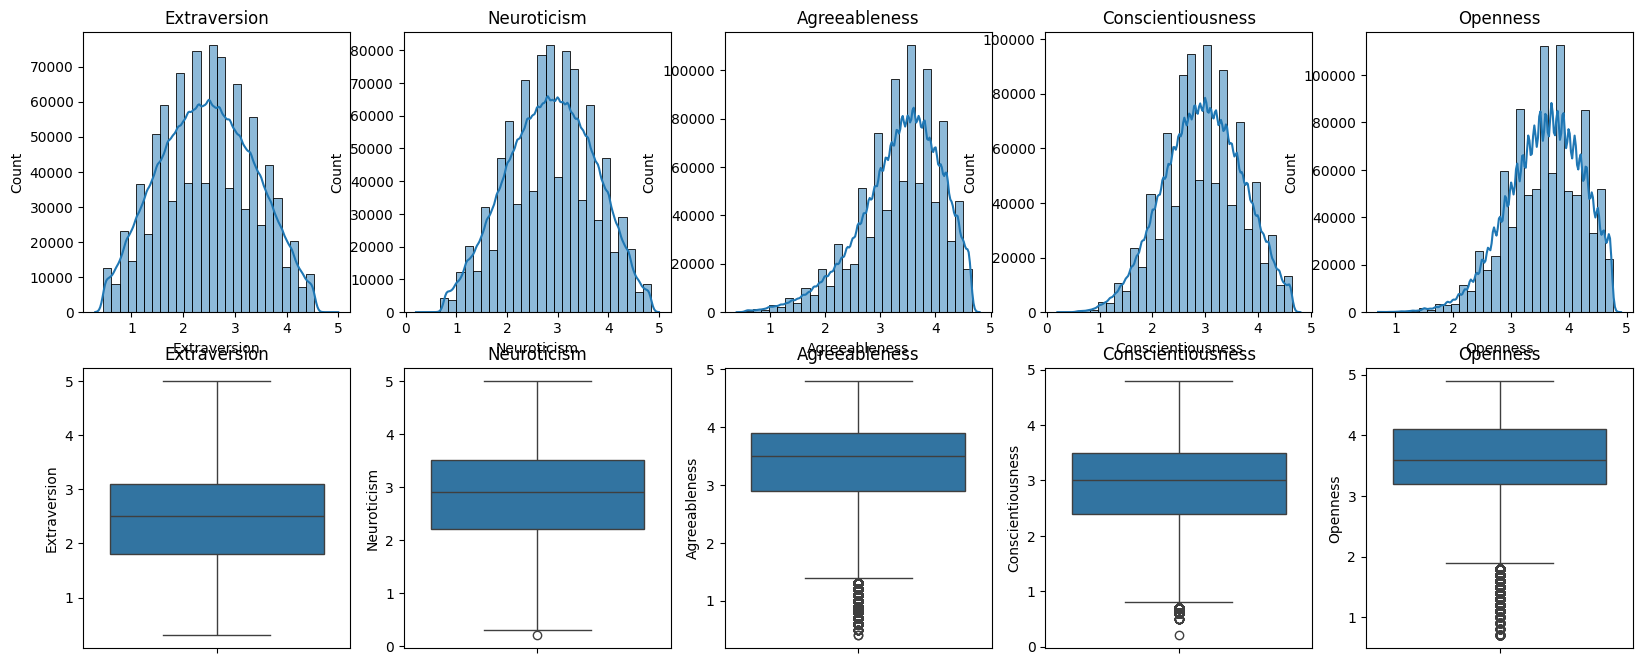

In [ ]:
#histogram and boxplot
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, trait in enumerate(traits):
    sns.histplot(df[trait], bins=30, kde=True, ax=axes[0, i]).set_title(trait)
    sns.boxplot(y=df[trait], ax=axes[1, i]).set_title(trait)

plt.show()

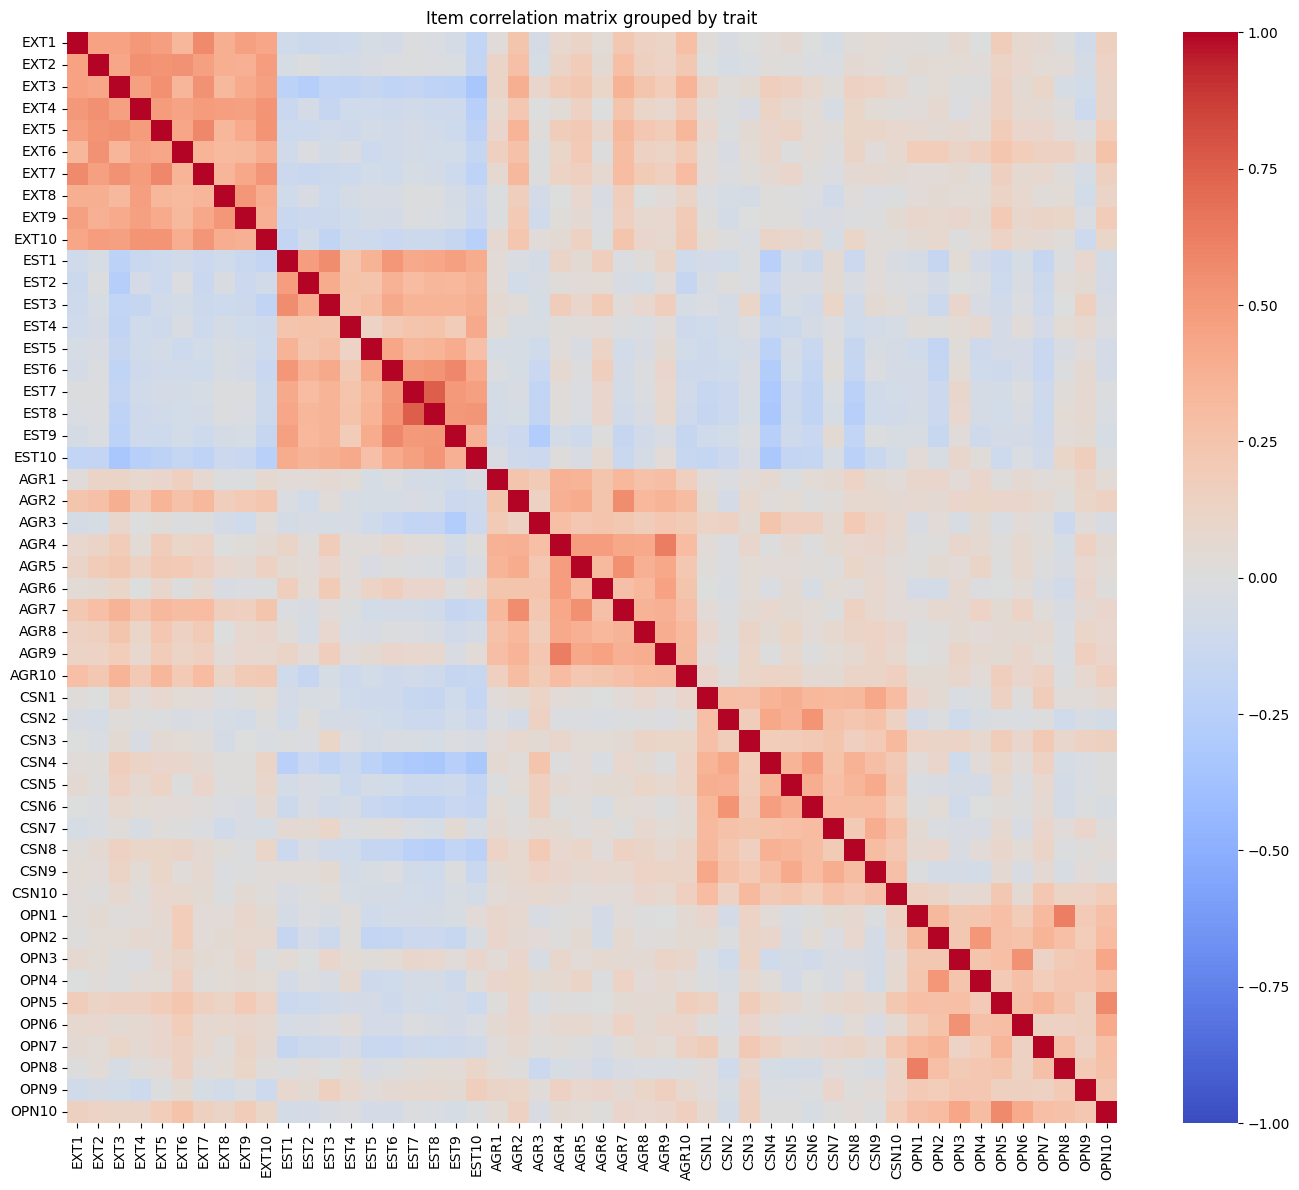

In [ ]:
# all item correlation map
item_corr = df[item_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(item_corr, cmap='coolwarm', vmin=-1, vmax=1) # the vim/max stop it auto-creating its own zoomed in bit of scale
plt.title('Item correlation matrix grouped by trait')
plt.tight_layout()

plt.show()

In [ ]:
# trait correlation map
trait_corr = df[traits].corr()

sns.heatmap(trait_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Trait correlation matrix')

plt.show()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

# radar chart of average trait scores
avg_scores = df[traits].mean()
fig = go.Figure()
fig.add_trace(go.Scatterpolar(r=avg_scores.values, theta=traits, fill='toself', name='Average'))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 5])),
                   title='Average Big Five trait scores')
fig.write_html('output/radar_chart.html')
fig.show()



In [ ]:
fig2 = px.scatter_matrix(
    df.sample(10000, random_state=42),
    dimensions=traits,
    opacity=0.4,
    title='Scatter matrix of Big Five traits'
)

fig2.update_traces(diagonal_visible=False, marker=dict(size=3))
fig2.update_layout(width=1000, height=1000)
fig2.write_html('output/scatter_matrix.html')
fig2.show()